# 자연어와 단어의 분산 표현
컴퓨터가 우리의 말을 알아듣게 만드는 것을 해볼 것이다.

## 자연어 처리 NLP
우리의 말을 컴퓨터에게 이해시키기 위한 기술분야이다. 목표는 사람의 말을 컴퓨터가 이해하도록 만들어서, 컴퓨터가 우리에게 도움이 되는 일을 수행하게 하는 것이다. 컴퓨터 언어는 딱딱하지만 자연어는 같은 의미를 다양하게 표현하는 등 부드럽다. 그래서 컴퓨터에게 이해를 시켜서 사람들에게 도움이 되게 하는게 목표다. 

### 단어의 의미
컴퓨터에게 단어의 의미를 이해시키는 것이 중요하다. 이해 시키는 법으로 시소러스, 통계 기반, 추론 기반 기법이 있다. 

시소러스
유의어 사전이라는 뜻이다. 뜻이 같거나 비슷한 단어가 한 그룹으로 모여있다. 단어들의 관계를 그래프로 표현하여 단어 사이의 연결를 정의할 수 있고 이 단어 네트워크로 단어 사이의 관계를 가르칠 수 있다. 그래서 여기서 가장 유명한 시소러스는 WordNet이다. WordNet을 사용하면 유의어와 단어 사이의 유사도를 구할 수 있다. 하지만 사람이 수작업으로 레이블링 하는 방식이여서 시대의 변화에 대응할 수 없고 사람을 쓰는 비용도 크며 단어의 미묘한 차이를 표현할 수 없다. 이후에 나올 기법을 사용하면 사람은 사용하지 않아도 된다.

통계 기반 기법
NLP연구나 애플리케이션을 염두하고 수집한 대량의 텍스트 데이터인 말뭉치를 이용한다. 말뭉치는 사람이 쓴 글이며 사람의 지식이 충분히 담겨 있다. 그래서 이 기법의 목표는 말뭉치에서 자동으로, 효율적으로 핵심을 추출하는 것이다.
다음은 기법을 알기 위한 말뭉치 전처리 코드이다.

In [1]:
import numpy as np
def preprocess(text):
    text = text.lower()
    text = text.replace('.', ' .')
    words = text.split(' ')
    word_to_id = {}
    id_to_word = {}
    for word in words:
        if word not in word_to_id:
            new_id = len(word_to_id)
            word_to_id[word] = new_id
            id_to_word[new_id] = word
    corpus = np.array([word_to_id[w] for w in words])

    return corpus, word_to_id, id_to_word

text = "you say goodby and i say hello."
corpus, word_to_id, id_to_word = preprocess(text)
print(corpus, word_to_id, id_to_word)

[0 1 2 3 4 1 5 6] {'you': 0, 'say': 1, 'goodby': 2, 'and': 3, 'i': 4, 'hello': 5, '.': 6} {0: 'you', 1: 'say', 2: 'goodby', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}


간결하고 이치에 맞게 벡터 표현을 단어라는 영역에서도 구축할 수 있을까? 즉 원하는 바는 단어의 의미를 정확하게 파악할 수 있는 벡터 표현이다. 이를 NLP 에서는 단어의 분산표현이라고 한다. 그래서 많은 연구가 이루어졌지만 모두 하나의 아이디어를 뿌리에 두고 있다. 이 아이디어는 단어의 의미는 주변 단어에 의해 형성된다는 것이다. 이를 분포 가설이라고 한다. 다시 말해 단어 자체에는 의미가 없지만 그 단어가 사용된 주변 단어인 맥락이 의미를 형성한다는 것이다.

동시 발생 행렬  
분포 가설에 기초해서 단어를 벡터로 나타낼 방법을 생각해보자. 주변에 어떤 단어가 몇번이나 등장하였는지 세어 집계하는 방식을 사용한다. 그리고 이것을 행으로 하고 이를 모으면 행렬의 형태가 되어 동시 발생 행렬이 된다. 이를 한 번 코드로 구현 해보자.

In [2]:
import numpy as np

def create_co_matrix(corpus, vocab_size, window_size=1):
    '''동시발생 행렬 생성

    :param corpus: 말뭉치(단어 ID 목록)
    :param vocab_size: 어휘 수
    :param window_size: 윈도우 크기(윈도우 크기가 1이면 타깃 단어 좌우 한 단어씩이 맥락에 포함)
    :return: 동시발생 행렬
    '''
    corpus_size = len(corpus)
    co_matrix = np.zeros((vocab_size, vocab_size), dtype=np.int32)

    for idx, word_id in enumerate(corpus):
        for i in range(1, window_size + 1):
            left_idx = idx - i
            right_idx = idx + i

            if left_idx >= 0:
                left_word_id = corpus[left_idx]
                co_matrix[word_id, left_word_id] += 1

            if right_idx < corpus_size:
                right_word_id = corpus[right_idx]
                co_matrix[word_id, right_word_id] += 1

    return co_matrix

이로써 단어를 벡터로 표현하는 방법을 알 수 있었고 벡터 사이의 유사도를 측정하는 방법을 생각해보자. 방법은 다양하지만 그 중에서 코사인 유사도를 자주 사용한다. $\text{Similarity}(\mathbf{A}, \mathbf{B}) = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}$ $\text{Similarity}(\mathbf{A}, \mathbf{B}) = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \sqrt{\sum_{i=1}^{n} B_i^2}}$ 분자에는 내적이 분모에는 L2 노름이 등장한다. 코드는 아래와 같다. 그리고 이 유사도를 실제 어떻게 구현 되는지 살펴 보자. 결과를 살펴 보면 코사인 유사도는 -1에서 1까지 값이 도출 되는데 0.7이므로 유사도가 비교적 높다고 할 수 있다.

In [4]:
def cos_similarity(x, y, eps=1e-8):
    '''코사인 유사도 산출

    :param x: 벡터
    :param y: 벡터
    :param eps: '0으로 나누기'를 방지하기 위한 작은 값
    :return:
    '''
    nx = x / (np.sqrt(np.sum(x ** 2)) + eps)
    ny = y / (np.sqrt(np.sum(y ** 2)) + eps)
    return np.dot(nx, ny)

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)
vocab_size = len(word_to_id)
C = create_co_matrix(corpus, vocab_size)

c0 = C[word_to_id['you']]  # "you"의 단어 벡터
c1 = C[word_to_id['i']]    # "i"의 단어 벡터
print(cos_similarity(c0, c1))

0.7071067691154799


어떤 검색어가 주어지면 그 단어와 비슷한 단어를 유사도 순서로 출력 하는 함수도 구현 해보자 아래와 같다.

In [6]:
def most_similar(query, word_to_id, id_to_word, word_matrix, top=5):
    '''유사 단어 검색

    :param query: 쿼리(텍스트)
    :param word_to_id: 단어에서 단어 ID로 변환하는 딕셔너리
    :param id_to_word: 단어 ID에서 단어로 변환하는 딕셔너리
    :param word_matrix: 단어 벡터를 정리한 행렬. 각 행에 해당 단어 벡터가 저장되어 있다고 가정한다.
    :param top: 상위 몇 개까지 출력할 지 지정
    '''
    if query not in word_to_id:
        print('%s(을)를 찾을 수 없습니다.' % query)
        return

    print('\n[query] ' + query)
    query_id = word_to_id[query]
    query_vec = word_matrix[query_id]

    # 코사인 유사도 계산
    vocab_size = len(id_to_word)

    similarity = np.zeros(vocab_size)
    for i in range(vocab_size):
        similarity[i] = cos_similarity(word_matrix[i], query_vec)

    # 코사인 유사도를 기준으로 내림차순으로 출력
    count = 0
    for i in (-1 * similarity).argsort():
        if id_to_word[i] == query:
            continue
        print(' %s: %s' % (id_to_word[i], similarity[i]))

        count += 1
        if count >= top:
            return

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)
vocab_size = len(word_to_id)
C = create_co_matrix(corpus, vocab_size)

most_similar('you', word_to_id, id_to_word, C, top=5)


[query] you
 goodbye: 0.7071067691154799
 hello: 0.7071067691154799
 i: 0.7071067691154799
 and: 0.0
 say: 0.0


### 통계 기반 기법 개선하기
동시발생 행렬은 두 단어가 동시에 발생한 횟수를 나타내는데 발생 횟수는 좋은 특징이 아닐 수 있다. 예를 들어서 the 같은 경우에는 단어간의 연관성을 나타내기에는 좀 어렵다. 그래서 이 문제를 해결하기 위해서 점별 상호정보량(PMI)라는 척도를 이용한다. $PMI(x, y) = \log_2 \frac{P(x, y)}{P(x)P(y)}$ 이고 각각은 변수가 일어날 확률이다. 하지만 이 지표도 동시발생 횟수가 0이면 -무한대가 되므로 문제가 발생해서 PPMI 양의 상호정보량을 이용한다. $PPMI(x, y) = \max(PMI(x, y), 0)$ 이를 코드로 구현 해보자. 하지만 이 PPMI에도 문제가 있는데 말뭉치의 어휘가 증가할 수록 단어 벡터의 차원 수도 증가해버린다는 것이다. 그리고 안에 0이 많듯이 대부분의 원소가 중요하지 않다 추가로 벡터는 노이즈에 약하기 때문에 견고하지 못하다.

In [7]:
def ppmi(C, verbose=False, eps = 1e-8):
    '''PPMI(점별 상호정보량) 생성

    :param C: 동시발생 행렬
    :param verbose: 진행 상황을 출력할지 여부
    :return:
    '''
    M = np.zeros_like(C, dtype=np.float32)
    N = np.sum(C)
    S = np.sum(C, axis=0)
    total = C.shape[0] * C.shape[1]
    cnt = 0

    for i in range(C.shape[0]):
        for j in range(C.shape[1]):
            pmi = np.log2(C[i, j] * N / (S[j]*S[i]) + eps)
            M[i, j] = max(0, pmi)

            if verbose:
                cnt += 1
                if cnt % (total//100 + 1) == 0:
                    print('%.1f%% 완료' % (100*cnt/total))
    return M

W = ppmi(C)
np.set_printoptions(precision=3)
print("동시발생 행렬")
print(C)
print('-'*50)
print('PPMI')
print(W)

동시발생 행렬
[[0 1 0 0 0 0 0]
 [1 0 1 0 1 1 0]
 [0 1 0 1 0 0 0]
 [0 0 1 0 1 0 0]
 [0 1 0 1 0 0 0]
 [0 1 0 0 0 0 1]
 [0 0 0 0 0 1 0]]
--------------------------------------------------
PPMI
[[0.    1.807 0.    0.    0.    0.    0.   ]
 [1.807 0.    0.807 0.    0.807 0.807 0.   ]
 [0.    0.807 0.    1.807 0.    0.    0.   ]
 [0.    0.    1.807 0.    1.807 0.    0.   ]
 [0.    0.807 0.    1.807 0.    0.    0.   ]
 [0.    0.807 0.    0.    0.    0.    2.807]
 [0.    0.    0.    0.    0.    2.807 0.   ]]


차원감소, 그래서 중요한 정보는 최대한 유지하면서 벡터의 차원을 줄여서 해결한다. 이 행렬은 희소행렬(Sparse matrix)의 꼴을 하고 있다. 이를 밀집 행렬 벡터로 바꾸는 작업이 필요하다. 그래서 차원을 줄이는 다양한 방법이 있지만 그 중에서 특이값 분해인 SVD를 사용한다. $A = U \Sigma V^T$ 여기서 U와 V는 직교 행렬이고 서로의 열벡터는 서로 직교하고 시그마는 대각행렬이다. 여기서 U 행렬은 어떤 공간의 기저를 형성한다. 그래서 맥락적으로 단어 공간으로 취급 가능하다. 그리고 시그마 행렬은 대각 행렬로 대각 성분으로 특이값이 큰 순서로 나열되어 있다. 이를 맥락적으로 옮기면 해당 기저의 중요도라고 간주할 수 있다. 그래서 중요도가 높은 벡터만 뽑아서 즉 대각 성분에서 왼쪽 위와 곱해지는 기저만 뽑아서 새로운 행렬 X를 만들 수 있다. 이를 코드로 살펴보자.  
문제는 SVD 분해가 O(n^3) 이여서 많이 느리다. 그래서 truncted SVD 같은 기법을 사용하곤 한다.

동시발생 행렬 [0 1 0 0 0 0 0]
PPMI [0.    1.807 0.    0.    0.    0.    0.   ]
SVD [-1.110e-16  3.409e-01 -1.205e-01 -4.163e-16 -1.110e-16 -9.323e-01
 -2.426e-17]
[-1.110e-16  3.409e-01]


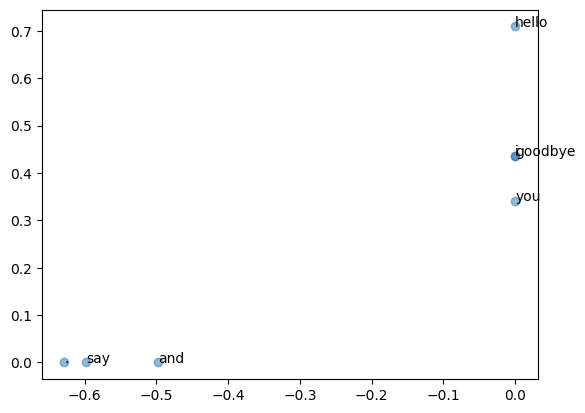

In [10]:
import matplotlib.pyplot as plt

U, S, V = np.linalg.svd(W)

print('동시발생 행렬', C[0])
print('PPMI', W[0])
print('SVD', U[0])
# 2차원 벡터로 차원 감소
print(U[0, :2])

# 그래프로 나타내기
for word, word_id in word_to_id.items():
    plt.annotate(word, (U[word_id, 0], U[word_id, 1]))

plt.scatter(U[:, 0], U[:, 1], alpha=.5)
plt.show()

다음은 PTB 데이터 셋을 이용해서 통계 기반 기법을 적용해보자.

In [12]:
import sys
sys.path.append('..')
from dataset import ptb

#ptb 불러오고 내용 살펴보기
corpus, word_to_id, id_to_word = ptb.load_data('train')

print('말뭉치 크기:', len(corpus))
print('corpus[:30]:', corpus[:30])
print()
print('id_to_word[0]:', id_to_word[0])
print('id_to_word[1]:', id_to_word[1])
print('id_to_word[2]:', id_to_word[2])
print()
print("word_to_id['car']:", word_to_id['car'])
print("word_to_id['happy']:", word_to_id['happy'])
print("word_to_id['lexus']:", word_to_id['lexus'])

# 기법 적용하기
import sys
sys.path.append('..')
import numpy as np
from dataset import ptb


window_size = 2
wordvec_size = 100

corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)
print('동시발생 수 계산 ...')
C = create_co_matrix(corpus, vocab_size, window_size)
print('PPMI 계산 ...')
W = ppmi(C, verbose=True)

print('calculating SVD ...')
try:
    # truncated SVD (빠르다!)
    from sklearn.utils.extmath import randomized_svd
    U, S, V = randomized_svd(W, n_components=wordvec_size, n_iter=5,
                             random_state=None)
except ImportError:
    # SVD (느리다)
    U, S, V = np.linalg.svd(W)

word_vecs = U[:, :wordvec_size]

querys = ['you', 'year', 'car', 'toyota']
for query in querys:
    most_similar(query, word_to_id, id_to_word, word_vecs, top=5)

말뭉치 크기: 929589
corpus[:30]: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

id_to_word[0]: aer
id_to_word[1]: banknote
id_to_word[2]: berlitz

word_to_id['car']: 3856
word_to_id['happy']: 4428
word_to_id['lexus']: 7426
동시발생 수 계산 ...
PPMI 계산 ...
1.0% 완료
2.0% 완료
3.0% 완료
4.0% 완료
5.0% 완료
6.0% 완료
7.0% 완료
8.0% 완료
9.0% 완료
10.0% 완료
11.0% 완료
12.0% 완료
13.0% 완료
14.0% 완료
15.0% 완료
16.0% 완료
17.0% 완료
18.0% 완료
19.0% 완료
20.0% 완료
21.0% 완료
22.0% 완료
23.0% 완료
24.0% 완료
25.0% 완료
26.0% 완료
27.0% 완료
28.0% 완료
29.0% 완료
30.0% 완료
31.0% 완료
32.0% 완료
33.0% 완료
34.0% 완료
35.0% 완료
36.0% 완료
37.0% 완료
38.0% 완료
39.0% 완료
40.0% 완료
41.0% 완료
42.0% 완료
43.0% 완료
44.0% 완료
45.0% 완료
46.0% 완료
47.0% 완료
48.0% 완료
49.0% 완료
50.0% 완료
51.0% 완료
52.0% 완료
53.0% 완료
54.0% 완료
55.0% 완료
56.0% 완료
57.0% 완료
58.0% 완료
59.0% 완료
60.0% 완료
61.0% 완료
62.0% 완료
63.0% 완료
64.0% 완료
65.0% 완료
66.0% 완료
67.0% 완료
68.0% 완료
69.0% 완료
70.0% 완료
71.0% 완료
72.0% 완료
73.0% 완료
74.0% 완료
75.0% 완료
76.0% 완료
77.0% 완료
78.0% 완료
79.0% 완료
80.0% 완